# EDA — Medical Abstracts TC Corpus

Análise exploratória do corpus usado para treinar o classificador de triagem
(`src/triagem/model/train.py`). Reaproveita o código de produção
(`triagem.data.download`, `triagem.data.prepare`) em vez de reimplementar a
leitura dos dados, para que qualquer conclusão aqui valha também para o que
roda em produção.

Fonte: [Medical Abstracts TC Corpus](https://github.com/sebischair/Medical-Abstracts-TC-Corpus).

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from triagem.config import get_settings
from triagem.data.download import download_dataset
from triagem.data.prepare import (
    CONDITION_NAMES,
    LABEL_COLUMN,
    TEXT_COLUMN,
    load_split,
    split_train_validation,
)

plt.rcParams["figure.dpi"] = 110
settings = get_settings()
paths = download_dataset(settings.data_dir / "raw")
paths

{'train': WindowsPath('C:/Users/Bianca.Seixas/mlet-tech-challenge-fase3/data/raw/medical_tc_train.csv'),
 'test': WindowsPath('C:/Users/Bianca.Seixas/mlet-tech-challenge-fase3/data/raw/medical_tc_test.csv'),
 'labels': WindowsPath('C:/Users/Bianca.Seixas/mlet-tech-challenge-fase3/data/raw/medical_tc_labels.csv')}

## 1. Volume e limpeza

In [2]:
raw_train = pd.read_csv(paths["train"])
raw_test = pd.read_csv(paths["test"])

train = load_split(paths["train"])
test = load_split(paths["test"])

print(f"train bruto:   {len(raw_train):>6} linhas")
print(f"train limpo:   {len(train):>6} linhas  ({len(raw_train) - len(train)} descartadas)")
print(f"test bruto:    {len(raw_test):>6} linhas")
print(f"test limpo:    {len(test):>6} linhas  ({len(raw_test) - len(test)} descartadas)")
print(f"duplicatas de texto (train): {train[TEXT_COLUMN].duplicated().sum()}")

train bruto:    11550 linhas
train limpo:    11550 linhas  (0 descartadas)
test bruto:      2888 linhas
test limpo:      2888 linhas  (0 descartadas)
duplicatas de texto (train): 2105


`load_split` (o mesmo código do pipeline de treino) descarta linhas sem texto ou rótulo. O
volume descartado aqui é o piso de qualidade do dado bruto — se crescer numa atualização do
corpus, é sinal de mudança na fonte que merece investigação antes de treinar.

A quantidade de duplicatas de texto acima é detalhada na próxima seção.

## 2. Duplicatas e ambiguidade de rótulo

O corpus repete o mesmo texto de abstract sob rótulos diferentes em múltiplas linhas —
provável resíduo de uma versão multi-rótulo do dataset original, achatada para um único
rótulo por linha. Como a vetorização é determinística, um texto idêntico gera o mesmo vetor
de entrada duas vezes, e nenhum classificador determinístico consegue acertar as duas
ocorrências quando o rótulo esperado difere entre elas. Esta seção mede o tamanho desse
teto, de modo que um desempenho abaixo do esperado possa ser separado entre capacidade do
modelo e ambiguidade do dado.

In [3]:
todos_ct = pd.concat([train, test], ignore_index=True)
por_texto = todos_ct.groupby(TEXT_COLUMN)[LABEL_COLUMN]

n_grupos_ambiguos = (por_texto.nunique() > 1).sum()
maior_por_grupo = por_texto.apply(lambda s: s.value_counts().iloc[0])
teto_acuracia = maior_por_grupo.sum() / len(todos_ct)

print(f"linhas totais (train+test):              {len(todos_ct)}")
print(f"textos únicos:                            {todos_ct[TEXT_COLUMN].nunique()}")
print(f"grupos de texto idêntico c/ rótulos diferentes: {n_grupos_ambiguos}")
print(f"teto teórico de acurácia (TF-IDF, 1 predição por texto): {teto_acuracia:.4f}")

linhas totais (train+test):              14438
textos únicos:                            11227
grupos de texto idêntico c/ rótulos diferentes: 2929
teto teórico de acurácia (TF-IDF, 1 predição por texto): 0.7776


In [4]:
treino, validacao = split_train_validation(
    train, validation_size=settings.validation_size, seed=settings.random_seed
)
overlap_val = set(treino[TEXT_COLUMN]) & set(validacao[TEXT_COLUMN])
overlap_test = set(train[TEXT_COLUMN]) & set(test[TEXT_COLUMN])
linhas_teste_repetidas = test[TEXT_COLUMN].isin(overlap_test).sum()

print(f"treino x validação (seed={settings.random_seed}): {len(overlap_val)} textos em comum")
print(f"linhas de teste com texto do treino: {linhas_teste_repetidas} de {len(test)}")

treino x validação (seed=42): 657 textos em comum
linhas de teste com texto do treino: 1010 de 2888


**Isso não é vazamento no sentido usual** (memorizar texto→rótulo e "colar" na validação): em
nenhuma das ocorrências sobrepostas treino/validação ou treino/teste o rótulo se repete — é
sempre um rótulo diferente para o mesmo texto. O overlap não infla o f1-macro reportado; pelo
contrário, tende a penalizá-lo, já que o modelo pode aprender no treino um rótulo que é
"errado" para a mesma frase na validação ou no teste.

O teto teórico de ~78% de acurácia explica parte do platô: o f1-macro do campeão (~0,58,
documentado no [model card](../docs/model_card.md)) não está limitado apenas pela capacidade
do modelo — uma fração do corpus tem rótulo genuinamente ambíguo para qualquer classificador
baseado no texto. Esse teto está registrado na seção "Limitações" do model card. Deduplicação
(mantendo só uma ocorrência por texto, ou votando o rótulo majoritário do grupo) é uma
melhoria de dado possível para trabalho futuro; ela fica fora do escopo desta análise
exploratória porque reabre a calibração do piso de qualidade (`min_f1_macro`) e os números já
publicados — decisão de modelagem, não de EDA.

## 3. Distribuição de classes

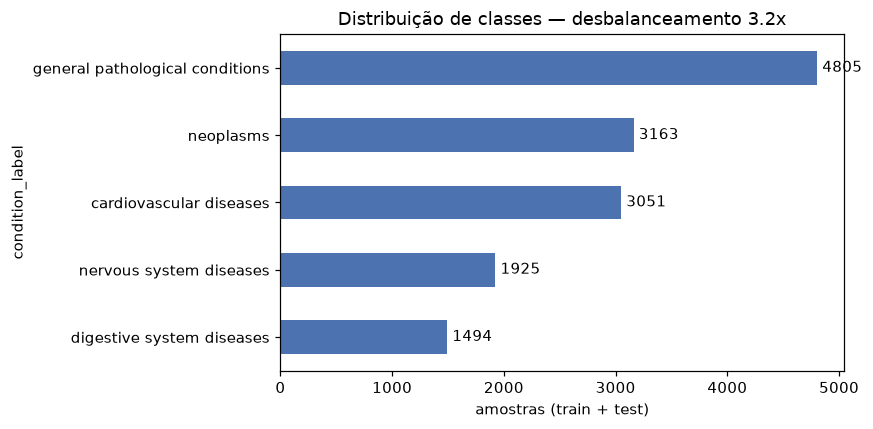

condition_label
digestive system diseases          1494
nervous system diseases            1925
cardiovascular diseases            3051
neoplasms                          3163
general pathological conditions    4805
Name: count, dtype: int64

In [5]:
todos = pd.concat([train.assign(split="train"), test.assign(split="test")], ignore_index=True)
contagem = todos[LABEL_COLUMN].map(CONDITION_NAMES).value_counts().sort_values()
razao_desbalanceamento = contagem.max() / contagem.min()

fig, ax = plt.subplots(figsize=(8, 4))
contagem.plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("amostras (train + test)")
ax.set_title(f"Distribuição de classes — desbalanceamento {razao_desbalanceamento:.1f}x")
for i, v in enumerate(contagem):
    ax.text(v, i, f" {v}", va="center")
plt.tight_layout()
plt.show()

contagem

O desbalanceamento de ~3x entre a classe mais e a menos frequente é a razão de duas
decisões do pipeline de treino: `class_weight="balanced"` nos classificadores e f1-macro
(em vez de acurácia) como métrica de seleção do campeão — acurácia recompensaria acertar só
a classe majoritária.

## 4. Tamanho dos textos

count    14438.0
mean       179.9
std         76.5
min         24.0
25%        122.0
50%        176.0
75%        235.0
max        596.0
Name: n_palavras, dtype: float64


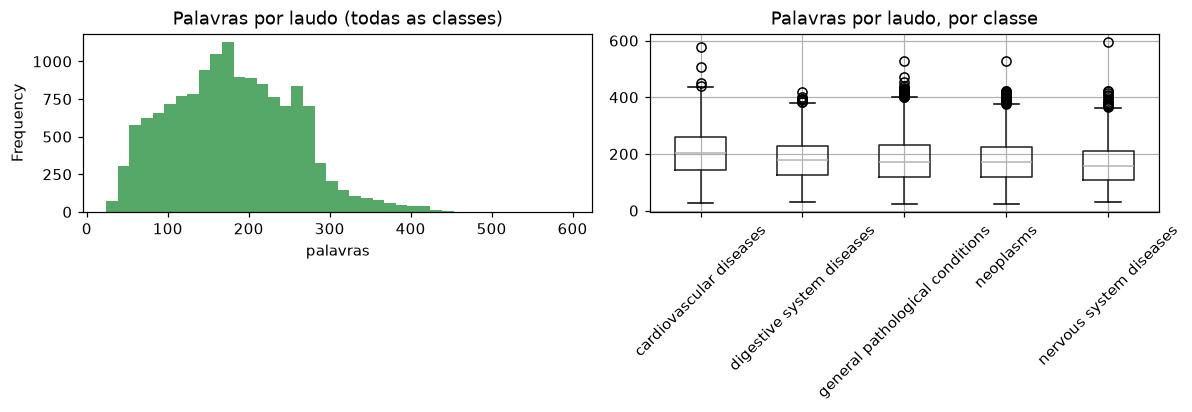

In [6]:
todos["n_palavras"] = todos[TEXT_COLUMN].str.split().str.len()
todos["n_caracteres"] = todos[TEXT_COLUMN].str.len()
todos["condicao"] = todos[LABEL_COLUMN].map(CONDITION_NAMES)

print(todos["n_palavras"].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
todos["n_palavras"].plot.hist(bins=40, ax=axes[0], color="#55A868")
axes[0].set_title("Palavras por laudo (todas as classes)")
axes[0].set_xlabel("palavras")

todos.boxplot(column="n_palavras", by="condicao", ax=axes[1], rot=45)
axes[1].set_title("Palavras por laudo, por classe")
axes[1].set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()

Textos curtos (poucas dezenas de palavras) são o cenário que o teste de contrato da API
cobre com a rejeição HTTP 422 — o mesmo motivo por trás do laudo "curto" que o alvo
`make traffic` injeta a cada 10 requisições para popular o painel de taxa de erro.

## 5. Termos mais frequentes por classe

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Mesma configuração de stopwords/acentuação do vetorizador de produção
# (`triagem.model.train._build_vectorizer`), mas sem n-gramas para o top-termos
# ficar legível como palavras isoladas.
vectorizer = TfidfVectorizer(
    max_features=3_000, min_df=2, strip_accents="unicode", lowercase=True, stop_words="english"
)
tfidf = vectorizer.fit_transform(train[TEXT_COLUMN])
termos = vectorizer.get_feature_names_out()

for label_id, nome in CONDITION_NAMES.items():
    mask = (train[LABEL_COLUMN] == label_id).to_numpy()
    media_por_termo = tfidf[mask].mean(axis=0).A1
    top = media_por_termo.argsort()[::-1][:10]
    print(f"{nome:35s} {', '.join(termos[i] for i in top)}")

neoplasms                           patients, cancer, tumor, cell, carcinoma, cells, tumors, cases, treatment, breast
digestive system diseases           patients, disease, liver, gastric, hepatitis, bowel, esophageal, treatment, biliary, patient
nervous system diseases             patients, pain, syndrome, brain, cerebral, disease, nerve, treatment, patient, stroke
cardiovascular diseases             patients, coronary, pressure, ventricular, artery, blood, heart, hypertension, myocardial, left
general pathological conditions     patients, group, treatment, disease, cases, patient, acute, syndrome, years, study


Os termos de maior peso TF-IDF por classe são vocabulário clínico específico da condição
(ex. termos oncológicos em `neoplasms`, cardíacos em `cardiovascular diseases`), o que
explica por que um modelo linear sobre TF-IDF já captura sinal razoável sem embeddings — a
análise completa de por que a Regressão Logística venceu está no
[baseline](02_analise_baseline.ipynb).

## 6. Exemplo de laudo por classe

In [8]:
for label_id, nome in CONDITION_NAMES.items():
    exemplo = train.loc[train[LABEL_COLUMN] == label_id, TEXT_COLUMN].iloc[0]
    print(f"--- {nome} ---")
    print(exemplo[:280] + ("..." if len(exemplo) > 280 else ""))
    print()

--- neoplasms ---
Neuropeptide Y and neuron-specific enolase levels in benign and malignant pheochromocytomas. Neuron-specific enolase (NSE) is the isoform of enolase, a glycolytic enzyme found in the neuroendocrine system. Neuropeptide Y (NPY) is a peptide recently discovered in the peripheral an...

--- digestive system diseases ---
Sexually transmitted diseases of the colon, rectum, and anus. The challenge of the nineties. During the past two decades, an explosive growth in both the prevalence and types of sexually transmitted diseases has occurred. Up to 55 percent of homosexual men with anorectal complain...

--- nervous system diseases ---
Does carotid restenosis predict an increased risk of late symptoms, stroke, or death? The identification of carotid restenosis as an unexpected late complication of carotid endarterectomy has prompted concerns regarding its importance as a source of new cerebral symptoms, stroke,...

--- cardiovascular diseases ---
Pharmacomechanical thrombolys

## Conclusões

- O corpus tem poucas linhas descartadas pela validação de schema, mas uma fração relevante
  (~26% dos textos únicos) se repete sob rótulos diferentes — impondo um teto teórico de
  acurácia de ~78% para qualquer classificador baseado só no texto. É a explicação de fundo
  mais provável para o f1-macro do campeão estacionar em ~0,58: parte é capacidade do
  modelo, parte é ambiguidade irredutível do rótulo. Esse teto está registrado no model
  card; deduplicação/voto majoritário é uma melhoria de dado possível para trabalho futuro.
- O desbalanceamento de classes (~3x) já é tratado no pipeline de produção via
  `class_weight` balanceado e f1-macro como métrica de decisão — não é um problema em
  aberto, é uma característica do dado que já molda o código.
- O vocabulário é fortemente discriminativo por classe (termos clínicos específicos), o que
  favorece um modelo linear leve sobre TF-IDF em vez de um modelo mais pesado — ponto de
  partida para a comparação de candidatos em
  [`02_analise_baseline.ipynb`](02_analise_baseline.ipynb).
- Textos muito curtos existem no corpus real; a API rejeita entradas abaixo do mínimo de
  caracteres por contrato (ver `tests/api/test_api.py`), não por limitação do modelo.